In [1]:
# pip install kagglehub[pandas-datasets]
#%pip install 
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("novandraanugrah/bitcoin-historical-datasets-2018-2024")

print("Path to dataset files:", path)

c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\SAYHI\.cache\kagglehub\datasets\novandraanugrah\bitcoin-historical-datasets-2018-2024\versions\288


In [2]:
path+=r'\btc_4h_data_2018_to_2025.csv'
df=pd.read_csv(path)
df.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000,13715.65,13715.65,13155.38,13410.03,1676.204807,2018-01-01 03:59:59.999000,2.251607e+07,19438,739.518666,9.937537e+06,0
1,2018-01-01 04:00:00.000000,13434.98,13818.55,13322.15,13570.35,1302.214836,2018-01-01 07:59:59.999000,1.770254e+07,18061,588.516222,7.998796e+06,0
2,2018-01-01 08:00:00.000000,13569.98,13735.24,13001.13,13220.56,1319.755931,2018-01-01 11:59:59.999000,1.765121e+07,17200,582.668293,7.792109e+06,0
3,2018-01-01 12:00:00.000000,13220.56,13330.00,12750.00,13247.00,1831.933153,2018-01-01 15:59:59.999000,2.391259e+07,21357,830.314747,1.083304e+07,0
4,2018-01-01 16:00:00.000000,13247.00,13290.65,12940.00,13240.37,1092.337234,2018-01-01 19:59:59.999000,1.434887e+07,13178,557.453779,7.324320e+06,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17127 entries, 0 to 17126
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     17126 non-null  object 
 1   Open                          17127 non-null  float64
 2   High                          17127 non-null  float64
 3   Low                           17127 non-null  float64
 4   Close                         17127 non-null  float64
 5   Volume                        17127 non-null  float64
 6   Close time                    17126 non-null  object 
 7   Quote asset volume            17127 non-null  float64
 8   Number of trades              17127 non-null  int64  
 9   Taker buy base asset volume   17127 non-null  float64
 10  Taker buy quote asset volume  17127 non-null  float64
 11  Ignore                        17127 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 1.6+ MB


In [4]:
# Clean column names (strip spaces)
df.columns = df.columns.str.strip()

# Parse datetime
df['Open time'] = pd.to_datetime(df['Open time'])
df['Close time'] = pd.to_datetime(df['Close time'])

# Convert numeric columns
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 
                'Quote asset volume', 'Number of trades',
                'Taker buy base asset volume', 'Taker buy quote asset volume']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop 'Ignore' column if present
if 'Ignore' in df.columns:
    df = df.drop(columns=['Ignore'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17127 entries, 0 to 17126
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Open time                     17126 non-null  datetime64[ns]
 1   Open                          17127 non-null  float64       
 2   High                          17127 non-null  float64       
 3   Low                           17127 non-null  float64       
 4   Close                         17127 non-null  float64       
 5   Volume                        17127 non-null  float64       
 6   Close time                    17126 non-null  datetime64[ns]
 7   Quote asset volume            17127 non-null  float64       
 8   Number of trades              17127 non-null  int64         
 9   Taker buy base asset volume   17127 non-null  float64       
 10  Taker buy quote asset volume  17127 non-null  float64       
dtypes: datetime64[ns](2), float6

In [6]:
df.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume
0,2018-01-01 00:00:00,13715.65,13715.65,13155.38,13410.03,1676.204807,2018-01-01 03:59:59.999,2.251607e+07,19438,739.518666,9.937537e+06
1,2018-01-01 04:00:00,13434.98,13818.55,13322.15,13570.35,1302.214836,2018-01-01 07:59:59.999,1.770254e+07,18061,588.516222,7.998796e+06
2,2018-01-01 08:00:00,13569.98,13735.24,13001.13,13220.56,1319.755931,2018-01-01 11:59:59.999,1.765121e+07,17200,582.668293,7.792109e+06
3,2018-01-01 12:00:00,13220.56,13330.00,12750.00,13247.00,1831.933153,2018-01-01 15:59:59.999,2.391259e+07,21357,830.314747,1.083304e+07
4,2018-01-01 16:00:00,13247.00,13290.65,12940.00,13240.37,1092.337234,2018-01-01 19:59:59.999,1.434887e+07,13178,557.453779,7.324320e+06


In [7]:
df = df.sort_values('Open time')
df = df.set_index('Open time')

In [8]:
df.head()

,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume
Open time,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13155.38,13410.03,1676.204807,2018-01-01 03:59:59.999,2.251607e+07,19438,739.518666,9.937537e+06
2018-01-01 04:00:00,13434.98,13818.55,13322.15,13570.35,1302.214836,2018-01-01 07:59:59.999,1.770254e+07,18061,588.516222,7.998796e+06
2018-01-01 08:00:00,13569.98,13735.24,13001.13,13220.56,1319.755931,2018-01-01 11:59:59.999,1.765121e+07,17200,582.668293,7.792109e+06
2018-01-01 12:00:00,13220.56,13330.00,12750.00,13247.00,1831.933153,2018-01-01 15:59:59.999,2.391259e+07,21357,830.314747,1.083304e+07
2018-01-01 16:00:00,13247.00,13290.65,12940.00,13240.37,1092.337234,2018-01-01 19:59:59.999,1.434887e+07,13178,557.453779,7.324320e+06


In [9]:
# Check missing data
print(df.isna().sum())

# Fill or interpolate missing data
df = df.interpolate(method='linear')

Open                            0
High                            0
Low                             0
Close                           0
Volume                          0
Close time                      1
Quote asset volume              0
Number of trades                0
Taker buy base asset volume     0
Taker buy quote asset volume    0
dtype: int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17127 entries, 2018-01-01 00:00:00 to NaT
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Open                          17127 non-null  float64       
 1   High                          17127 non-null  float64       
 2   Low                           17127 non-null  float64       
 3   Close                         17127 non-null  float64       
 4   Volume                        17127 non-null  float64       
 5   Close time                    17127 non-null  datetime64[ns]
 6   Quote asset volume            17127 non-null  float64       
 7   Number of trades              17127 non-null  int64         
 8   Taker buy base asset volume   17127 non-null  float64       
 9   Taker buy quote asset volume  17127 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 1.4 MB


In [103]:
'''# Price-based features
df['Price Change'] = df['Close'] - df['Open']
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['High'] - df['Low']

# Rolling statistics
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['STD_10'] = df['Close'].rolling(window=10).std()

# Volume-weighted average price
df['VWAP'] = (df['Quote asset volume'] / df['Volume']).fillna(0)'''

"# Price-based features\ndf['Price Change'] = df['Close'] - df['Open']\ndf['Return'] = df['Close'].pct_change()\ndf['Volatility'] = df['High'] - df['Low']\n\n# Rolling statistics\ndf['MA_10'] = df['Close'].rolling(window=10).mean()\ndf['MA_50'] = df['Close'].rolling(window=50).mean()\ndf['STD_10'] = df['Close'].rolling(window=10).std()\n\n# Volume-weighted average price\ndf['VWAP'] = (df['Quote asset volume'] / df['Volume']).fillna(0)"

In [104]:
'''daily = df.resample('1D').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()'''

"daily = df.resample('1D').agg({\n    'Open': 'first',\n    'High': 'max',\n    'Low': 'min',\n    'Close': 'last',\n    'Volume': 'sum'\n}).dropna()"

In [105]:
'''from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])'''

"from sklearn.preprocessing import MinMaxScaler\n\nscaler = MinMaxScaler()\nscaled_cols = ['Open', 'High', 'Low', 'Close', 'Volume']\ndf[scaled_cols] = scaler.fit_transform(df[scaled_cols])"

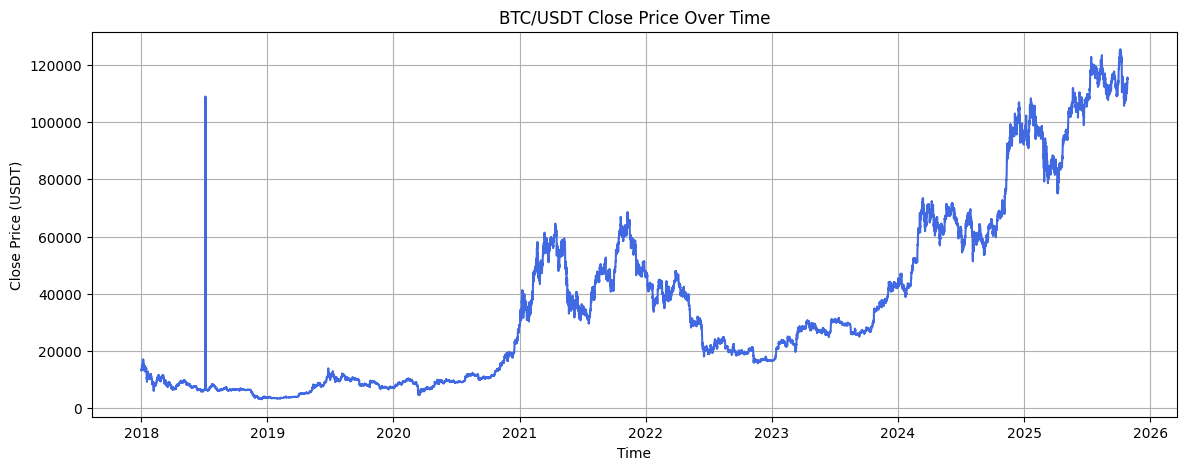

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

plt.figure(figsize=(14,5))
plt.plot(df['Close'], color='royalblue')
plt.title('BTC/USDT Close Price Over Time')
plt.xlabel('Time')
plt.ylabel('Close Price (USDT)')
plt.grid(True)
plt.show()

To extract trend, seasonality, and noise, we use seasonal_decompose.
For a 4-hour dataset, there are 6 intervals per day, 42 per week — so period=42 often makes sense.

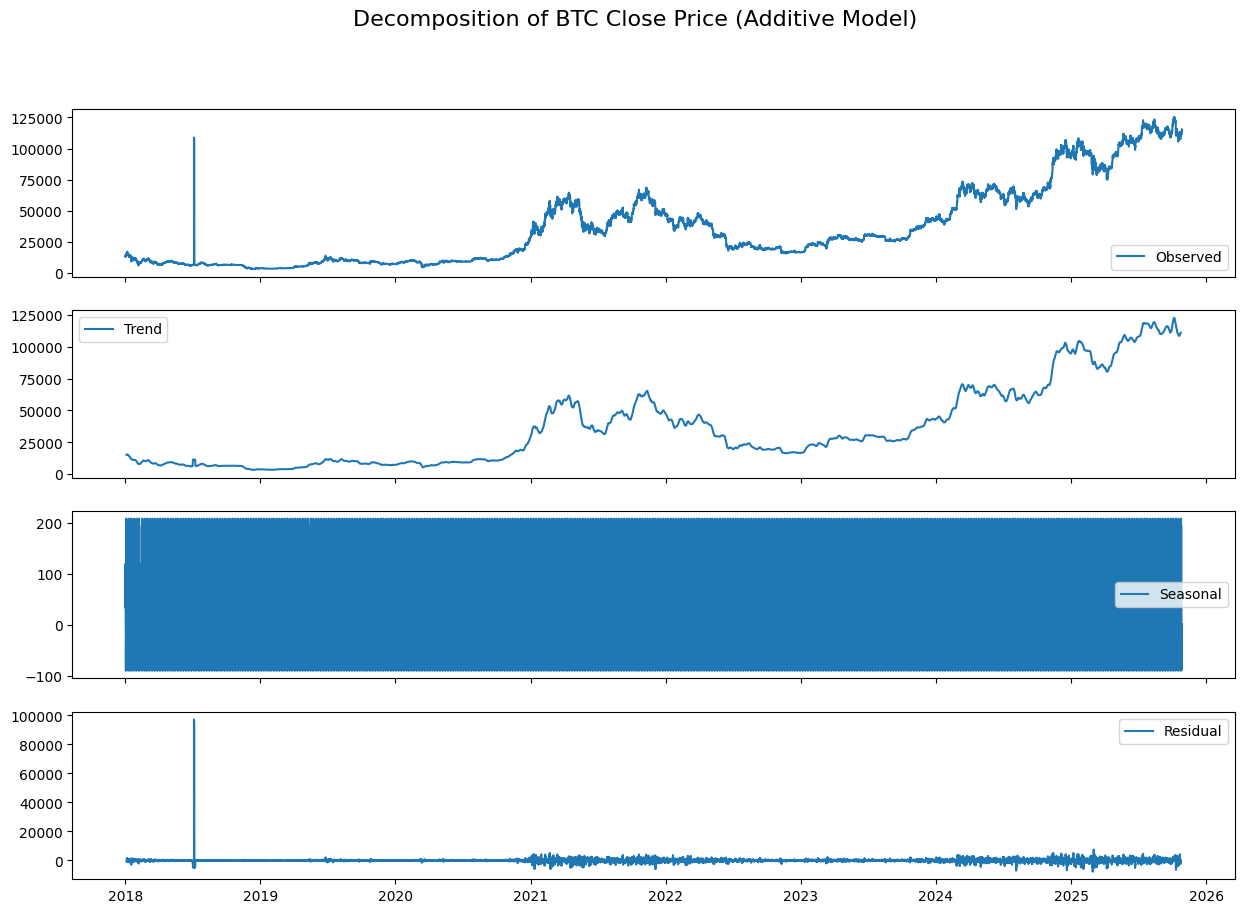

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import numpy as np

# Perform decomposition without extrapolation
decomposition = seasonal_decompose(df['Close'], model='additive', period=42)


# Create and plot components manually after dropping NaNs
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax1.plot(decomposition.observed.dropna(), label='Observed')
ax1.legend()

ax2.plot(decomposition.trend.dropna(), label='Trend')
ax2.legend()

ax3.plot(decomposition.seasonal.dropna(), label='Seasonal')
ax3.legend()

ax4.plot(decomposition.resid.dropna(), label='Residual')
ax4.legend()

plt.suptitle('Decomposition of BTC Close Price (Additive Model)', fontsize=16)
plt.show()


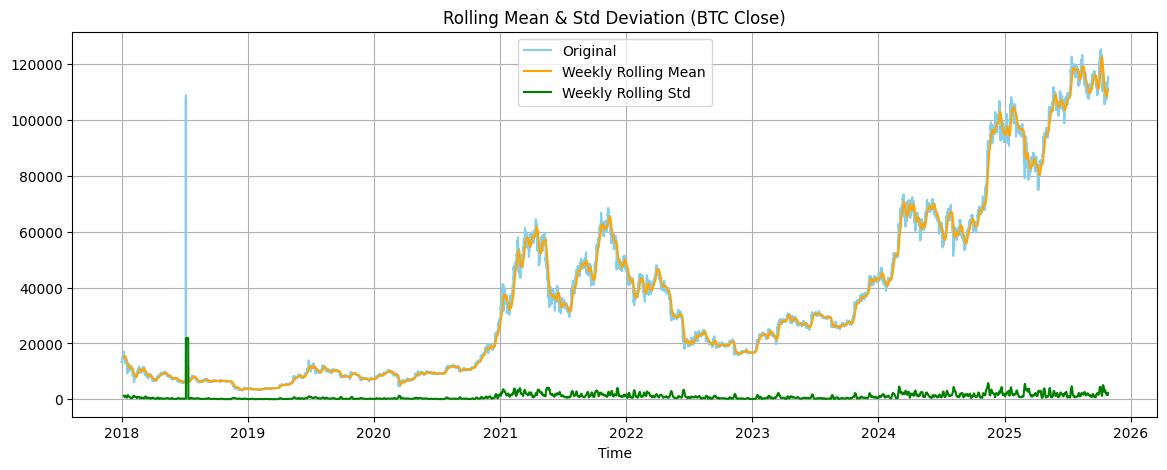

In [13]:
plt.figure(figsize=(14,5))
plt.plot(df['Close'], label='Original', color='skyblue')
plt.plot(df['Close'].rolling(window=42).mean(), label='Weekly Rolling Mean', color='orange')
plt.plot(df['Close'].rolling(window=42).std(), label='Weekly Rolling Std', color='green')
plt.title('Rolling Mean & Std Deviation (BTC Close)')
plt.xlabel('Time')
plt.legend()
plt.grid(True)
plt.show()


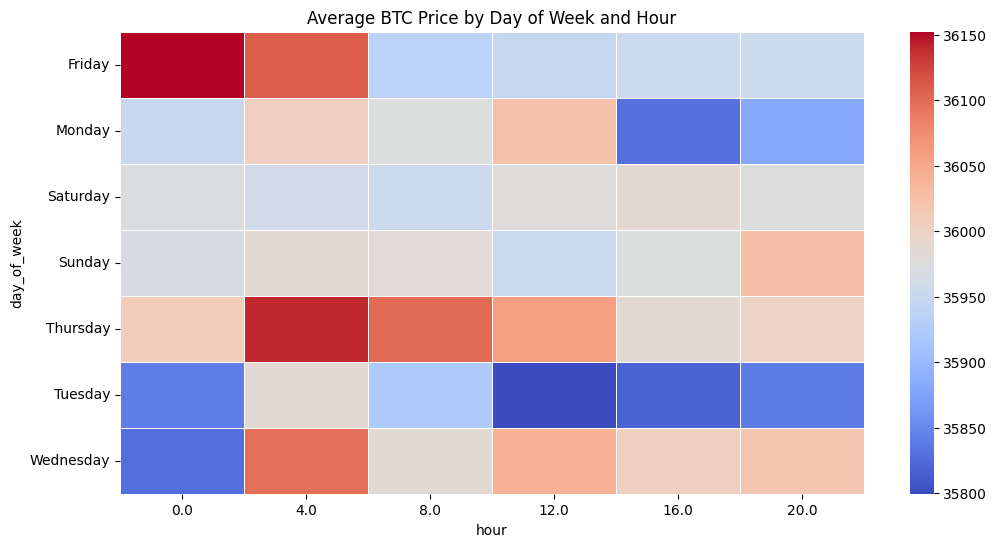

In [14]:
df['day_of_week'] = df.index.day_name()
df['hour'] = df.index.hour

# Average close by day/hour
pivot = df.pivot_table(values='Close', index='day_of_week', columns='hour', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm', linewidths=0.5)
plt.title('Average BTC Price by Day of Week and Hour')
plt.show()


### ARIMA

In [16]:

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Ensure we’re using only the 'Close' column for forecasting
btc = df[['Close']].copy()

train_size = int(len(btc) * 0.8)
train, test = btc.iloc[:train_size], btc.iloc[train_size:]

print("Train size:", train.shape)
print("Test size :", test.shape)

Train size: (13701, 1)
Test size : (3426, 1)


In [17]:
import pmdarima as pm
from pmdarima import model_selection
from sklearn.model_selection import train_test_split
import numpy as np


# Split data into training and testing sets
train, test = model_selection.train_test_split(btc, train_size=train_size)

# Fit auto_arima model
model = pm.auto_arima(train, seasonal=False, m=1)

# Make predictions
forecast = model.predict(test.shape[0])
model.summary()

c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\d

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                13701
Model:               SARIMAX(0, 1, 5)   Log Likelihood             -116003.747
Date:                Tue, 28 Oct 2025   AIC                         232019.494
Time:                        22:29:40   BIC                         232064.645
Sample:                             0   HQIC                        232034.542
                              - 13701                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7744      0.001  -1385.017      0.000      -0.776      -0.773
ma.L2          0.7013      0.001    601.205      0.000       0.699       0.704
ma.L3         -0.5657      0.001   -580.623      0.000      -0.568      -0.564
ma.L4         -0.0048      0.001     -6.383      0.000      -0.006      -0.003
ma.L5         -0.0074      0.001     -4.976      0.000      -0.010      -0.004
sigma2      1.332e+06    339.046   3927.340      0.000    1.33e+06    1.33e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):       12268250011.75
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               0.10   Skew:                            48.17
Prob(H) (two-sided):                  0.00   Kurtosis:                      4637.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [18]:
model.order

(0, 1, 5)

c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

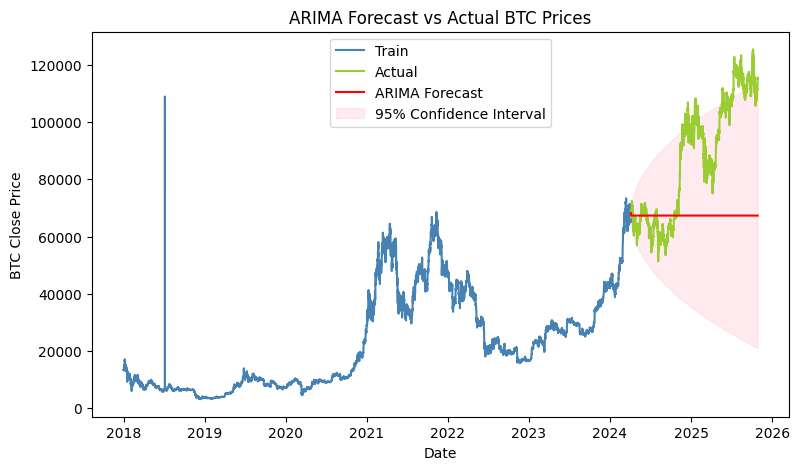

ARIMA Performance → MAE: 23237.58, RMSE: 29007.57, MAPE: 0.2335309


In [35]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Fit ARIMA model
model_arima = ARIMA(train['Close'], order=(0, 1, 5), enforce_invertibility=False)
fit_arima = model_arima.fit(cov_type='opg')

# Forecast with confidence intervals
forecast_object = fit_arima.get_forecast(steps=len(test))
forecast_mean = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

# Plot
plt.figure(figsize=(9, 5))
plt.plot(train['Close'], label='Train', color='steelblue')
plt.plot(test['Close'], label='Actual', color='yellowgreen')
plt.plot(test.index, forecast_mean, label='ARIMA Forecast', color='red')

# Add confidence intervals
plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title('ARIMA Forecast vs Actual BTC Prices')
plt.xlabel('Date')
plt.ylabel('BTC Close Price')
plt.legend()
plt.show()

# Evaluate
mae_arima = mean_absolute_error(test['Close'], forecast_mean)
rmse_arima = np.sqrt(mean_squared_error(test['Close'], forecast_mean))
mape_arima = mean_absolute_percentage_error(test['Close'], forecast_mean)

print(f"ARIMA Performance → MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.7f}")


### 🔍 **Interpretation of the ARIMA Forecast Plot**

1. **Historical Behavior (Train Data, Blue Line)**

   * Shows Bitcoin’s highly volatile price history, with multiple major cycles of sharp rises and drops.
   * The large spike around 2018–2019 looks like an outlier or data error, which may slightly affect the model fit.

2. **Actual (Test Data, Green Line)**

   * Represents the real observed BTC prices in the holdout period.
   * You can see that prices continued to show strong volatility and a generally upward trend through 2025.

3. **ARIMA Forecast (Red Line)**

   * The ARIMA(0,1,5) model has produced a **flat or near-flat forecast** after the training window.
   * This behavior is common with ARIMA models when the differenced series appears stationary (no strong trend component).
   * Essentially, the model expects **future BTC prices to hover around the last observed level**, rather than trend upward or downward.

4. **Confidence Interval (Pink Shaded Area)**

   * The cone-shaped widening shows **increasing uncertainty** over time.
   * By 2026, the range of potential prices is extremely wide — from perhaps under $40,000 to over $120,000 — reflecting the model’s growing lack of precision for long-term forecasts.
   * This indicates that while short-term projections might be somewhat reliable, **long-term ARIMA forecasts for BTC are not very actionable** due to high volatility and unpredictable market dynamics.

---

### 💼 **Business Implications**

1. **Short-Term Planning (Days–Weeks)**

   * ARIMA can provide **short-term directional signals** (stability or minor shifts) for trading or portfolio adjustments.
   * If confidence intervals are narrow, short-term forecasts might be used for **hedging or liquidity management**.

2. **Long-Term Forecasting (Months–Years)**

   * The flat forecast and broad uncertainty band suggest ARIMA alone is **not suitable for strategic forecasting** of BTC prices.
   * Businesses relying on BTC (e.g., crypto exchanges, payment processors, or mining firms) should **not base long-term financial decisions solely on ARIMA outputs**.

3. **Risk Management**

   * The widening confidence bands visually quantify **forecast risk** — useful for stress testing and scenario analysis.
   * Firms can use this to **set capital buffers** or **value-at-risk thresholds** under worst-case scenarios.

4. **Modeling Recommendations**

   * Since BTC is influenced by exogenous factors (macro conditions, regulations, sentiment), consider more advanced or hybrid models:

     * **ARIMAX / SARIMAX** (include exogenous predictors like trading volume or economic indices)
     * **LSTM / Prophet / hybrid ARIMA-LSTM** for capturing nonlinear patterns
     * **Volatility models (e.g., GARCH)** for better risk forecasting

---

### 🧭 **Summary Insight**

> The ARIMA model predicts BTC prices will remain near current levels in the short run, but exhibits wide uncertainty for the future.
> While statistically stable, this forecast highlights ARIMA’s limitation in capturing the speculative and regime-shifting nature of crypto markets.
> Businesses should use ARIMA results as a **baseline forecast** — complemented by market intelligence and more adaptive models for decision-making.


### Prophet

In [34]:
from prophet import Prophet
import pandas as pd
import numpy as np
import gc

# --- Prepare data ---
btc = df[['Close']]
df_prophet = btc.reset_index()
df_prophet.columns = ['ds', 'y']

# 1. Remove duplicates correctly
df_prophet = df_prophet.drop_duplicates(subset='ds', keep='first')

# 2. Split
train_prophet = df_prophet.iloc[:train_size].copy()
test_prophet  = df_prophet.iloc[train_size:].copy()

# 3. Rescale y
y_max = train_prophet['y'].max()
train_prophet['y'] = train_prophet['y'] / y_max

# 4. Downsample (Prophet handles ≤5000 points comfortably)
train_sample = train_prophet.iloc[::17, :].copy()   # every 3rd point

# --- Clear old Prophet binaries from memory ---
gc.collect()

# --- 5. Fit model safely ---
model_prophet = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.5
)

# Force the Newton optimizer directly (lighter on RAM)
model_prophet.fit(train_sample.tail(500), algorithm='LBFGS', iter=100)


00:51:51 - cmdstanpy - INFO - Chain [1] start processing
00:51:52 - cmdstanpy - INFO - Chain [1] done processing
00:51:52 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
00:51:52 - cmdstanpy - INFO - Chain [1] start processing
00:51:52 - cmdstanpy - INFO - Chain [1] done processing
00:51:52 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 


RuntimeError: Error during optimization! Command 'C:\Users\SAYHI\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=64744 data file=C:\Users\SAYHI\AppData\Local\Temp\tmpqp_0rpoa\j2l2ygw5.json init=C:\Users\SAYHI\AppData\Local\Temp\tmpqp_0rpoa\oosgkx8d.json output file=C:\Users\SAYHI\AppData\Local\Temp\tmpqp_0rpoa\prophet_model9hc5upxm\prophet_model-20251029005152.csv method=optimize algorithm=newton iter=100' failed: 